# Testing out dustapprox

[dustapprox docs](https://mfouesneau.github.io/dustapprox/examples.html)

## Imports

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import pandas as pd
import pyphot
from astropy import constants

from dustapprox.extinction import evaluate_extinction_model
from dustapprox.tools import generate_model
from dustapprox.models import PrecomputedModel
from dustapprox.models.polynomial import PolynomialModel

from gaianir_open_clusters.data import fetch_kurucz_models
from gaianir_open_clusters.config import DATA_DIRECTORY, RESULTS_DIRECTORY


import os
os.environ['OCELOT_DATA'] = (DATA_DIRECTORY / "ocelot_data").as_posix()

from ocelot.simulate.photometry import load_isochrone

In [2]:
# fetch_kurucz_models()

## Plotting extinction models in nm

(because i am bad at wavenumber)

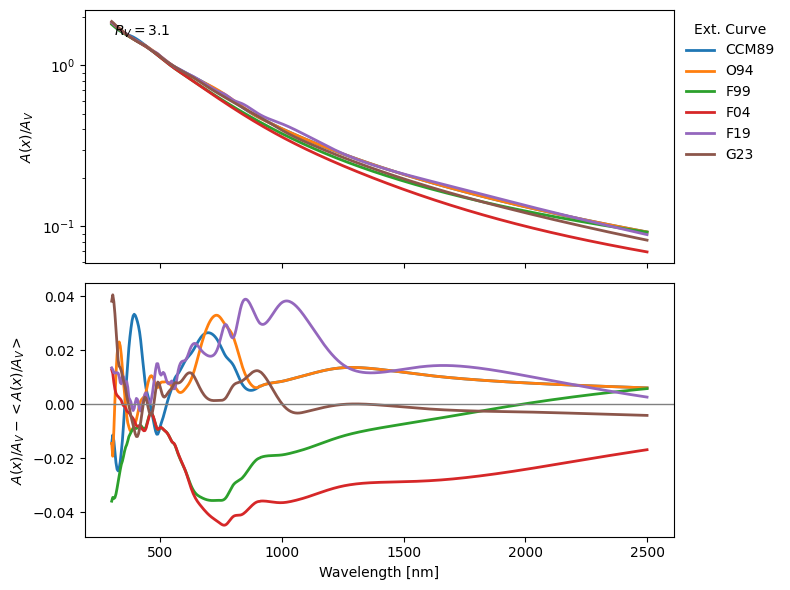

In [3]:
#define the wave numbers
x = np.linspace(300, 2500, num=500)
λ = x * u.nm

curves = 'CCM89', 'O94', 'F99', 'F04', 'F19', 'G23'
R0 = 3.1

curve_data = {}
_, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for name in curves:
    values = evaluate_extinction_model(name, λ, A0=1.0, R0=R0)
    curve_data[name] = values
    axes[0].plot(x, values, label=f'{name:s}', lw=2)

mean_curve = np.nanmean(list(curve_data.values()), axis=0)
for name, values in curve_data.items():
    diff = values - mean_curve
    axes[1].plot(x, diff, label=f'{name:s}', lw=2)

axes[0].set_ylabel(r'$A(x)/A_V$')
axes[0].legend(loc='upper left', frameon=False, title=r'Ext. Curve', bbox_to_anchor=(1.0, 1.0))
axes[0].text(0.05, 0.9, rf'$R_V={R0:.1f}$', transform=axes[0].transAxes)
axes[1].set_xlabel(r'Wavelength [nm]')
axes[1].set_ylabel(r'$A(x)/A_V - <A(x)/A_V>$')
axes[1].axhline(0.0, color='0.5', ls='-', lw=1)
# axes[0].set_ylim(-0.2, 5.2)
# axes[1].set_ylim(-0.42, 0.19)
axes[0].set_yscale("log")
plt.tight_layout()
plt.show()

## Trying to generate a model for one passband

In [4]:
model_pattern = (DATA_DIRECTORY / "models/Kurucz2003all/*.fl.dat.txt").as_posix()

points = np.linspace(0., 10, num=11)
# points[0] = 0.001

result = generate_model.generate_grid(
    model_pattern,
    "./dust.ecsv",
    ['GAIA/GAIA3.G', 'GAIA/GAIA3.Gbp', 'GAIA/GAIA3.Grp'],
    atmosphere_name="Kurucz (ODFNEW/NOVER 2003)",
    extinction_curve="G23",
    A0=points,
    R0=np.asarray([3.1]),
    n_jobs=6,
)

Computing photometric grid
   - Existing grid from dust.ecsv. Skipping computation and reloading from file.


In [5]:
features = "teff A0 R0".split()
model_output_path = "model.ecsv"

models = generate_model.train_polynomial_model(result, model_output_path, features, degree=3)
generate_model.export_trained_model_to_ecsv(model_output_path, models)

Training polynomial models for features: teff, A0, R0


fit: 100%|██████████| 3/3 [00:00<00:00,  3.51it/s]

Exporting grid to model.ecsv. done.


In [6]:
models

[PolynomialModel: GAIA_GAIA3.G 
    from: A0, R0, teffnorm   polynomial degree: 3,
 PolynomialModel: GAIA_GAIA3.Gbp 
    from: A0, R0, teffnorm   polynomial degree: 3,
 PolynomialModel: GAIA_GAIA3.Grp 
    from: A0, R0, teffnorm   polynomial degree: 3]

## Using the photometric grid for photometry too

### Working out what's going on

[None]

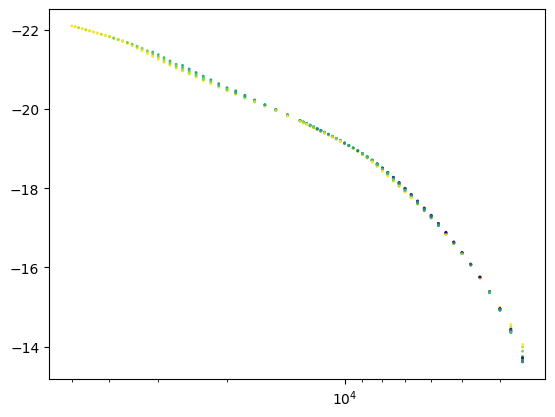

In [7]:
fig, ax = plt.subplots()

good = result.query("feh==0.0 and alpha==0.0 and A0==0.0 and passband=='GAIA_GAIA3.G'").reset_index(
    drop=True
)

# distance_correction =

ax.scatter(good["teff"], good["mag"], s=1, c=good['logg'])
ax.invert_xaxis()
ax.invert_yaxis()
ax.set(xscale="log")

Those numbers look far too high. It turns out that Kurucz models are **surface photometry**, and need some adjustment...

In [8]:
models[0].predict(good)

array([0.91720593, 0.99706128, 0.90899274, 0.88335412, 0.9839271 ,
       0.93314187, 0.87446984, 1.16793173, 1.03297661, 0.86541401,
       1.07317929, 1.03297661, 1.00960618, 1.03846985, 0.99706128,
       1.08613277, 0.91720593, 1.16983825, 1.1533114 , 0.99056861,
       0.88335412, 1.03846985, 1.17182315, 1.14650308, 1.07317929,
       0.87446984, 1.16442573, 0.9839271 , 0.90061406, 1.15704122,
       1.1154375 , 1.09799214, 0.9839271 , 0.94843399, 0.99706128,
       1.16000051, 1.03297661, 0.94843399, 1.02157392, 0.90061406,
       0.88335412, 0.9558424 , 1.15704122, 1.06861125, 1.1485149 ,
       1.07317929, 0.89206835, 1.03846985, 1.17182315, 0.9630944 ,
       1.1017092 , 0.92525514, 1.07762121, 1.04904769, 1.02734514,
       1.18492223, 1.15407588, 0.9558424 , 1.03297661, 1.16787264,
       1.09020544, 1.06861125, 1.02734514, 0.93314187, 1.00340664,
       1.15909021, 1.08613277, 1.16442573, 0.93314187, 1.15407588,
       0.87446984, 1.1017092 , 0.97019151, 1.04382637, 0.97713

In [9]:
lib = PrecomputedModel()
r = lib.find(passband="Gaia")[0]
default_model = lib.load_model(r)
default_model[0].predict(good)  # * good['A0']

array([0.89748592, 0.96809511, 0.89027784, 0.86782859, 0.9564047 ,
       0.91149676, 0.8600665 , 1.12931389, 1.00026903, 0.85216291,
       1.03676526, 1.00026903, 0.97929624, 1.00522141, 0.96809511,
       1.04867704, 0.89748592, 1.1372957 , 1.12381067, 0.96231166,
       0.86782859, 1.00522141, 1.1349182 , 1.1062052 , 1.03676526,
       0.8600665 , 1.12513931, 0.9564047 , 0.88293306, 1.13003887,
       1.07604434, 1.05967136, 0.9564047 , 0.92497516, 0.96809511,
       1.13199026, 1.00026903, 0.92497516, 0.99001768, 0.88293306,
       0.86782859, 0.93151769, 1.13003887, 1.0325852 , 1.12391221,
       1.03676526, 0.87545037, 1.00522141, 1.1349182 , 0.93793072,
       1.06313784, 0.90455849, 1.04083979, 1.0147856 , 0.99520152,
       1.14469702, 1.12799092, 0.93151769, 1.00026903, 1.1364978 ,
       1.05244215, 1.0325852 , 0.99520152, 0.91149676, 0.97375623,
       1.12748919, 1.04867704, 1.12513931, 0.91149676, 1.12799092,
       0.8600665 , 1.06313784, 0.94421543, 1.01005987, 0.95037

AHHHHH. So, dustapprox predicts $A_x / A_0$ - so you have to multiply by $A_0$ to get extinction in that band.

### Getting photometry

So, I think that simply multiplying by the radius can get me from one to another...

In [10]:
class Params:
    log_age = np.log10(1e8)
    metallicity = 0.0


class Dummy:
    parameters = Params()


iso = load_isochrone(Dummy())
iso["teff"] = 10 ** iso["logTe"]
iso["lum"] = 10 ** iso["logL"] * constants.L_sun.value
iso["radius"] = np.sqrt(
    iso["lum"] / (4 * np.pi * constants.sigma_sb.value * iso["teff"] ** 4)
)

iso

,Zini,MH,logAge,Mini,int_IMF,Mass,logL,logTe,logg,label,...,Xo,Cexcess,Z,mbolmag,Gmag,G_BPmag,G_RPmag,teff,lum,radius
0,0.01471,0.0,7.99007,0.090000,1.081690,0.090,-2.745,3.4030,4.702,0,...,0.006496,-1.0,0.01476,11.634,13.677,16.450,12.201,2529.297996,6.886078e+23,1.536651e+08
1,0.01471,0.0,7.99007,0.094077,1.119634,0.094,-2.713,3.4076,4.707,0,...,0.006496,-1.0,0.01476,11.552,13.596,16.369,12.120,2556.230427,7.412623e+23,1.560900e+08
2,0.01471,0.0,7.99007,0.100000,1.171106,0.100,-2.665,3.4143,4.712,0,...,0.006496,-1.0,0.01476,11.433,13.476,16.251,12.000,2595.971977,8.278887e+23,1.599467e+08
3,0.01471,0.0,7.99007,0.102113,1.188520,0.102,-2.651,3.4162,4.714,0,...,0.006496,-1.0,0.01476,11.396,13.430,16.194,11.956,2607.354004,8.550114e+23,1.611295e+08
4,0.01471,0.0,7.99007,0.112812,1.270011,0.113,-2.576,3.4259,4.722,0,...,0.006496,-1.0,0.01476,11.211,13.130,15.746,11.682,2666.244668,1.016183e+24,1.679868e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,0.01471,0.0,7.99007,5.356968,2.615771,5.355,3.898,3.5724,0.511,7,...,0.005729,-1.0,0.01487,-4.974,-4.273,-3.255,-5.269,3735.940923,3.026718e+30,1.476642e+11
458,0.01471,0.0,7.99007,5.355704,2.615765,5.355,3.816,3.5805,0.625,7,...,0.005731,-1.0,0.01486,-4.771,-4.159,-3.219,-5.116,3806.273576,2.505947e+30,1.294420e+11
459,0.01471,0.0,7.99007,5.354951,2.615762,5.355,3.775,3.5845,0.682,7,...,0.005731,-1.0,0.01487,-4.667,-4.093,-3.182,-5.033,3841.492592,2.280195e+30,1.212202e+11
460,0.01471,0.0,7.99007,5.357528,2.615773,5.355,3.938,3.5683,0.454,7,...,0.005726,-1.0,0.01489,-5.075,-4.324,-3.259,-5.342,3700.837363,3.318730e+30,1.575706e+11


In [11]:
solar_values = iso.loc[iso['Mass'] == 1.0]
solar_values

,Zini,MH,logAge,Mini,int_IMF,Mass,logL,logTe,logg,label,...,Xo,Cexcess,Z,mbolmag,Gmag,G_BPmag,G_RPmag,teff,lum,radius


In [12]:
result.query("teff==10000 and alpha==0.0 and feh==-0.5 and logg==4.0 and A0==0").sort_values("teff")

,teff,logg,feh,alpha,passband,mag0,mag,A0,R0,Ax
20130,10000.0,4.0,-0.5,0.0,GAIA_GAIA3.G,-19.106995,-19.106995,0.0,3.1,0.0
20141,10000.0,4.0,-0.5,0.0,GAIA_GAIA3.Gbp,-19.647036,-19.647036,0.0,3.1,0.0
20152,10000.0,4.0,-0.5,0.0,GAIA_GAIA3.Grp,-18.350227,-18.350227,0.0,3.1,0.0


In [13]:
lib = pyphot.get_library()
filter = lib.load_filters(["Gaia_G"])[0]

Let's try with a few numbers just read off to check I understand this correctly:

In [14]:
# For the sun
-17.05197 -5 * np.log10((7e8 / (10 * u.pc).to(u.m).value)) - filter.Vega_zero_mag

np.float64(4.661668637976323)

In [15]:
# For vega
-19.106995 - 5 * np.log10((2.726 * constants.R_sun / (7.68 * u.pc).to(u.m)).value) - filter.Vega_zero_mag

np.float64(-0.13079933607635397)

So! the equation seems to be

$$
M = m_\text{surface} - 5 \log_{10} \left(\frac{R}{10\text{ pc}} \right) - m_\text{0}
$$

### A photometry helper

In [16]:
class Params:
    log_age = np.log10(3e6)
    metallicity = 0.0


class Dummy:
    parameters = Params()


iso = load_isochrone(Dummy())
iso["teff"] = 10 ** iso["logTe"]
iso["lum"] = 10 ** iso["logL"] * constants.L_sun.value
iso["radius"] = np.sqrt(
    iso["lum"] / (4 * np.pi * constants.sigma_sb.value * iso["teff"] ** 4)
)

iso

,Zini,MH,logAge,Mini,int_IMF,Mass,logL,logTe,logg,label,...,Xo,Cexcess,Z,mbolmag,Gmag,G_BPmag,G_RPmag,teff,lum,radius
0,0.01471,0.0,6.48003,0.090000,1.081690,0.090,-1.492,3.4293,3.553,0,...,0.006496,-1.000,0.01476,8.499,10.362,12.674,8.955,2687.200057,1.233025e+25,5.760699e+08
1,0.01471,0.0,6.48003,0.096515,1.141321,0.097,-1.478,3.4305,3.575,0,...,0.006496,-1.000,0.01476,8.465,10.311,12.608,8.907,2694.635332,1.273421e+25,5.822040e+08
2,0.01471,0.0,6.48003,0.101266,1.181592,0.101,-1.460,3.4322,3.584,0,...,0.006496,-1.000,0.01476,8.419,10.244,12.522,8.845,2705.203870,1.327309e+25,5.897598e+08
3,0.01471,0.0,6.48003,0.108154,1.235819,0.108,-1.439,3.4346,3.601,0,...,0.006496,-1.000,0.01476,8.367,10.163,12.413,8.770,2720.194762,1.393067e+25,5.975513e+08
4,0.01471,0.0,6.48003,0.114989,1.285362,0.115,-1.429,3.4357,3.622,0,...,0.006496,-1.000,0.01476,8.343,10.125,12.364,8.735,2727.093323,1.425515e+25,6.014163e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,0.01471,0.0,6.48003,95.693970,2.633510,58.376,6.271,4.6686,3.559,1,...,0.000124,6.270,0.01446,-10.909,-7.001,-7.149,-6.743,46622.976901,7.144501e+32,1.456717e+10
361,0.01471,0.0,6.48003,95.656929,2.633509,58.376,6.262,4.6258,3.397,0,...,0.000124,6.269,0.01446,-10.886,-7.259,-7.410,-6.993,42247.401299,6.997968e+32,1.755800e+10
362,0.01471,0.0,6.48003,95.670731,2.633509,58.376,6.266,4.6435,3.464,1,...,0.000124,6.269,0.01446,-10.895,-7.149,-7.299,-6.887,44004.794784,7.062719e+32,1.625830e+10
363,0.01471,0.0,6.48003,95.682060,2.633510,58.376,6.269,4.6564,3.513,1,...,0.000124,6.270,0.01446,-10.902,-7.073,-7.222,-6.813,45331.490615,7.111675e+32,1.537359e+10


In [17]:
iso['teff'].min()

np.float64(2687.200056717113)

In [18]:
PHOTOMETRIC_GRID = result.query("A0==0.0 and alpha==0.0 and R0==3.1").reset_index(
    drop=True
)

bands = PHOTOMETRIC_GRID["passband"].unique()
bands_short = [band.split(".")[1] for band in bands]

for band, band_long in zip(bands_short, bands):
    # Grab the Gaia filter
    filter_name = band
    if len(filter_name) > 1:
        filter_name = filter_name[1:]
    filter = lib.load_filters([f"Gaia_{filter_name.upper()}"])[0]

    # Copy photometry just to the valid set
    valid = PHOTOMETRIC_GRID["passband"] == band_long
    PHOTOMETRIC_GRID.loc[valid, band] = (
        PHOTOMETRIC_GRID.loc[valid, "mag0"] - filter.Vega_zero_mag
    )

mags = {band: pd.NamedAgg(band, "first") for band in bands_short}

PHOTOMETRIC_GRID = (
    PHOTOMETRIC_GRID.groupby(["teff", "logg", "feh"]).aggregate(**mags).reset_index()
)

PHOTOMETRIC_GRID

,teff,logg,feh,G,Gbp,Grp
0,3500.0,0.0,-2.5,-35.319389,-34.018051,-36.439766
1,3500.0,0.0,-2.0,-35.366230,-34.148735,-36.457401
2,3500.0,0.0,-1.5,-35.385765,-34.226326,-36.457840
3,3500.0,0.0,-1.0,-35.369240,-34.228119,-36.439701
4,3500.0,0.0,-0.5,-35.316803,-34.137615,-36.409508
...,...,...,...,...,...,...
3803,50000.0,5.0,-1.0,-43.559956,-43.729027,-43.241341
3804,50000.0,5.0,-0.5,-43.578644,-43.748714,-43.257195
3805,50000.0,5.0,0.0,-43.602486,-43.774044,-43.276642
3806,50000.0,5.0,0.2,-43.614670,-43.787056,-43.286263


In [19]:
from scipy.interpolate import NearestNDInterpolator, LinearNDInterpolator, interp1d

In [20]:
x = PHOTOMETRIC_GRID[["teff", "logg", "feh"]].to_numpy()
y = PHOTOMETRIC_GRID["G"]
y_big = PHOTOMETRIC_GRID[["G", "Gbp", "Grp"]]

linear_int = LinearNDInterpolator(x, y_big)
# nearest_int = NearestNDInterpolator(x, y_big, rescale=True)

In [21]:
min_log_g = (
    PHOTOMETRIC_GRID.groupby("teff")
    .aggregate(logg=pd.NamedAgg("logg", "min"))
    .reset_index()
)
min_log_g_interpolator = interp1d(
    min_log_g["teff"],
    min_log_g["logg"],
    bounds_error=False,
    fill_value=(min_log_g["logg"].min(), min_log_g["logg"].max()),
)

/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/matplotlib/collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


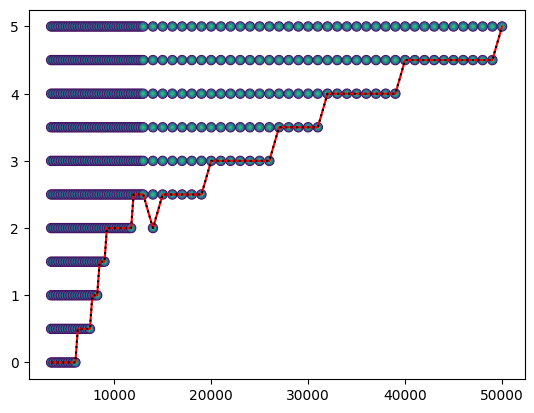

In [22]:
plt.scatter(
    PHOTOMETRIC_GRID["teff"],
    PHOTOMETRIC_GRID["logg"],
    c=PHOTOMETRIC_GRID["feh"],
    s=20 * (-PHOTOMETRIC_GRID["feh"] - PHOTOMETRIC_GRID["feh"].max() + 0.1),
)
plt.plot(min_log_g['teff'], min_log_g['logg'], 'r-')
plt.plot(min_log_g['teff'], min_log_g_interpolator(min_log_g['teff']), 'k:')


In [23]:
MIN_TEFF = PHOTOMETRIC_GRID["teff"].min()
MAX_TEFF = PHOTOMETRIC_GRID["teff"].max()
MAX_LOG_G = PHOTOMETRIC_GRID["logg"].max()


def get_photometry(data):
    # Lookup the values of the photometry
    values = data[["teff", "logg", "MH"]].copy()
    values["teff"] = np.clip(values["teff"], MIN_TEFF, MAX_TEFF)
    values["logg"] = np.clip(
        values["logg"], min_log_g_interpolator(values["teff"]), MAX_LOG_G
    )
    phot = linear_int(values.to_numpy())
    if np.any(np.isnan(phot)):
        raise RuntimeError("NaN photometry generated (somehow).")

    # Apply radius correction
    radii = 5 * np.log10(
        (data["radius"].to_numpy() / (10 * u.pc).to(u.m)).value
    ).reshape(-1, 1)

    # Apply temperature correction (sort of, lmao)
    temperature_offset = 4 * np.log10(values["teff"] / data["teff"]).to_numpy().reshape(
        -1, 1
    )

    return phot - radii + temperature_offset

In [36]:
iso_good = iso.query("label < 7")

g, bp, rp = get_photometry(iso_good).T

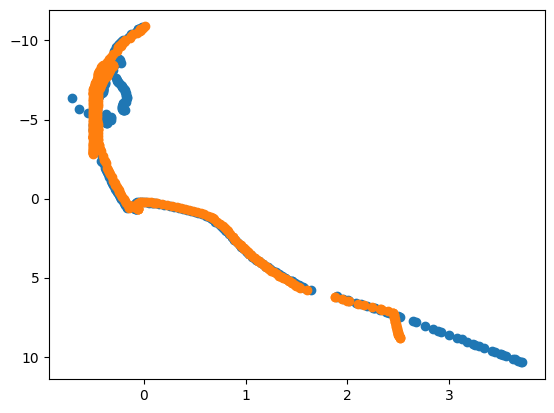

In [37]:
plt.scatter(iso_good['G_BPmag'] - iso_good['G_RPmag'], iso_good['Gmag'])
plt.scatter(bp - rp, g)
plt.gca().invert_yaxis()

In [26]:
iso_good['teff'].min()

np.float64(2687.200056717113)

ah fuck it sucks for M dwarfs

everyone hates M dwarfs

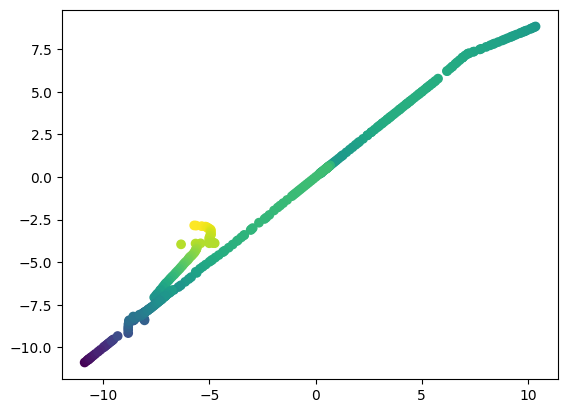

In [27]:
plt.scatter(iso['Gmag'], g, c=iso['logg'])

## Testing the final models

In [2]:
from gaianir_open_clusters.photometry import PhotometricModel

gaia_nir_phot = PhotometricModel()

In [20]:
class Params:
    log_age = np.log10(1e9)
    metallicity = 0.0


class Dummy:
    parameters = Params()


iso = load_isochrone(Dummy())
iso["teff"] = 10 ** iso["logTe"]
iso["lum"] = 10 ** iso["logL"] * constants.L_sun.value
iso["radius"] = np.sqrt(
    iso["lum"] / (4 * np.pi * constants.sigma_sb.value * iso["teff"] ** 4)
)

_ = gaia_nir_phot.predict(iso)


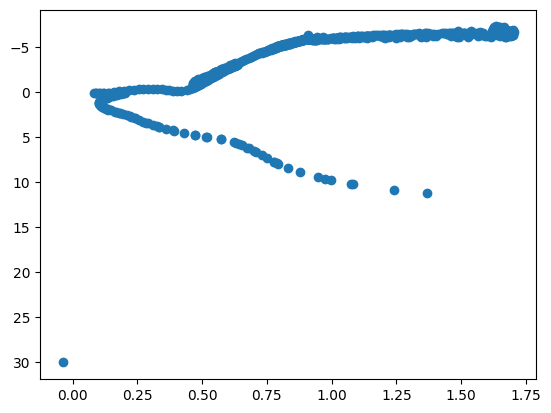

In [21]:
plt.scatter(iso['N_R'] - iso['N_J'], iso['N'])
plt.gca().invert_yaxis()

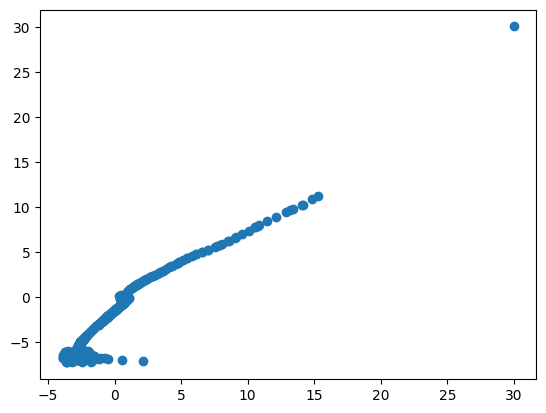

In [22]:
plt.scatter(iso['Gmag'], iso['N'])

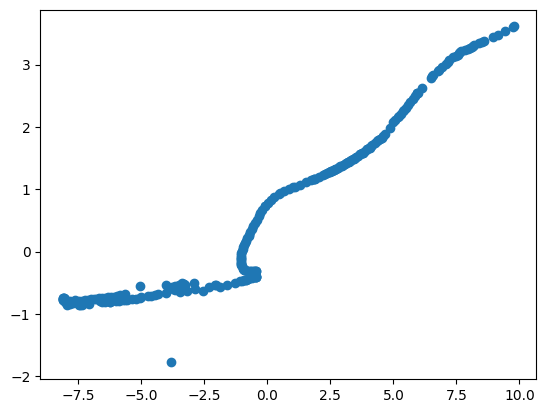

In [19]:
plt.scatter(iso['Gmag'], iso['Gmag'] - iso['N'])

In [31]:
ext = PolynomialModel.from_file(RESULTS_DIRECTORY / "extinction_model.ecsv", "N")

In [49]:
query_data = pd.DataFrame.from_dict({"A0": np.linspace(0, 50), "R0": 3.1, "teff": 3000})

In [50]:
ext.predict(query_data)

array([0.28434158, 0.27562431, 0.26736499, 0.25955016, 0.25216634,
       0.24520007, 0.23863787, 0.23246627, 0.22667182, 0.22124104,
       0.21616045, 0.2114166 , 0.20699601, 0.20288522, 0.19907075,
       0.19553914, 0.19227692, 0.18927062, 0.18650677, 0.1839719 ,
       0.18165254, 0.17953523, 0.1776065 , 0.17585287, 0.17426088,
       0.17281706, 0.17150795, 0.17032006, 0.16923994, 0.16825411,
       0.16734911, 0.16651147, 0.16572771, 0.16498438, 0.16426799,
       0.16356509, 0.16286221, 0.16214586, 0.1614026 , 0.16061894,
       0.15978142, 0.15887657, 0.15789092, 0.156811  , 0.15562335,
       0.15431449, 0.15287096, 0.15127928, 0.149526  , 0.14759763])